In [1]:
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/oscar/rt/9.6/25/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/lib/vscode/bin/remote-cli:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/rt/9.6/25/spack/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [2]:
import os.path as op

import matplotlib.pyplot as plt

from hnn_core import calcium_model, read_params, simulate_dipole, average_dipoles, read_dipole
from hnn_core.network_models import duecker_ET_model
from hnn_core.viz import plot_dipole
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd
import pickle
import numpy as np
from hnn_core import MPIBackend

--No graphics will be displayed.


In [3]:
import json
from hnn_core.hnn_io import read_network_configuration

# load BETA4 net (handtuned for now)
with open('/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_100_calcium_202602_optim.pkl', 'rb') as f:
    TEP_net = pickle.load(f)

def scale_and_smooth(dpls, window_len=10, scaling_factor=0.3):
    dpls_smoothed = deepcopy(dpls)
    for dpl in dpls_smoothed:
        dpl.smooth(window_len).scale(scaling_factor)
    return dpls_smoothed
    from hnn_core.viz import plot_spikes_raster

In [25]:
scaled_gabaa_nets = []

for scale in [10,5,1,0.2,0.1]:
    mod_net = deepcopy(TEP_net)
    mod_net.clear_connectivity()

    # add all the connections normally

    for conn_idx in np.arange(0,19,1):
        location = TEP_net.connectivity[conn_idx]['loc']
        receptor = TEP_net.connectivity[conn_idx]['receptor']
        weight = TEP_net.connectivity[conn_idx]['nc_dict']['A_weight']
        delay = TEP_net.connectivity[conn_idx]['nc_dict']['A_delay']
        lamtha = TEP_net.connectivity[conn_idx]['nc_dict']['lamtha']
        src_type = TEP_net.connectivity[conn_idx]['src_type']
        target_type = TEP_net.connectivity[conn_idx]['target_type']
        probability = TEP_net.connectivity[conn_idx]['probability']
    
        if receptor == 'gabaa':
            mod_net.add_connection(src_type, target_type, location, receptor,
                                weight*scale, delay, lamtha, probability=probability, # + 0.0002
                                conn_seed=3)
            print(src_type,target_type,receptor,scale)
        else:
            mod_net.add_connection(src_type, target_type, location, receptor,
                            weight, delay, lamtha, probability=probability,
                            conn_seed=3)

    
    scaled_gabaa_nets.append(mod_net)

L2_basket L2_pyramidal gabaa 10
L5_basket L5_pyramidal gabaa 10
L2_basket L5_pyramidal gabaa 10
L2_basket L2_basket gabaa 10
L5_basket L5_basket gabaa 10
L2_basket L2_pyramidal gabaa 5
L5_basket L5_pyramidal gabaa 5
L2_basket L5_pyramidal gabaa 5
L2_basket L2_basket gabaa 5
L5_basket L5_basket gabaa 5
L2_basket L2_pyramidal gabaa 1
L5_basket L5_pyramidal gabaa 1
L2_basket L5_pyramidal gabaa 1
L2_basket L2_basket gabaa 1
L5_basket L5_basket gabaa 1
L2_basket L2_pyramidal gabaa 0.2
L5_basket L5_pyramidal gabaa 0.2
L2_basket L5_pyramidal gabaa 0.2
L2_basket L2_basket gabaa 0.2
L5_basket L5_basket gabaa 0.2
L2_basket L2_pyramidal gabaa 0.1
L5_basket L5_pyramidal gabaa 0.1
L2_basket L5_pyramidal gabaa 0.1
L2_basket L2_basket gabaa 0.1
L5_basket L5_basket gabaa 0.1


In [26]:
scaled_gabaa_dpls = []

for net in scaled_gabaa_nets:
    with MPIBackend(n_procs=3, mpi_cmd='mpiexec'):
        dpl = simulate_dipole(net, tstop=250, n_trials=1,bsl_cor='duecker')
        scaled_gabaa_dpls.append(dpl)

MPI will run 1 trial(s) sequentially by distributing network neurons over 3 processes.
numprocs=3
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Applying calcium model baseline corr

In [27]:
smoothed_scaled_gabaa_dpls = []

for dpl in scaled_gabaa_dpls:
    dpl_copy = deepcopy(dpl)
    dpl_smoothed = scale_and_smooth(dpl_copy, scaling_factor=2.5,window_len=20)
    smoothed_scaled_gabaa_dpls.append(dpl_smoothed)


(0.0, 250.0)

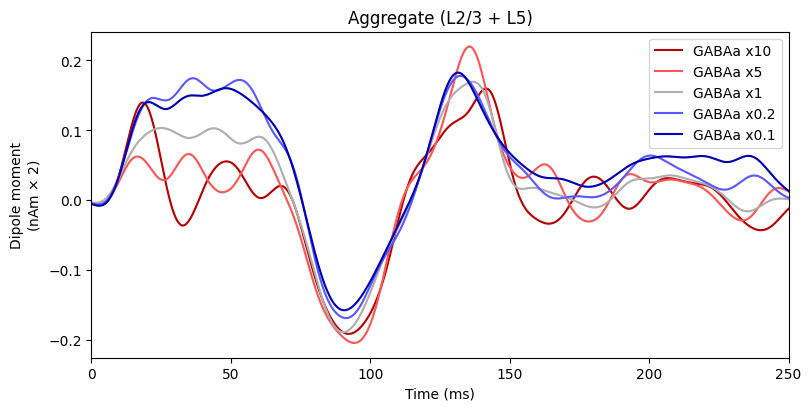

In [28]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
tstop=250
data_scale = 1
scale_list = [10,5,1,0.2,0.1]
color_list = ['#B60000','#FF5555','#AEAEAE','#5959FF','#0000B1']

# plot 2: dipoles and data
for idx, dpl in enumerate(smoothed_scaled_gabaa_dpls):
    dpl_copy = deepcopy(dpl)
    plot_dipole(dpl_copy, ax = axes, layer='agg', show=False, average=True,label=f'GABAa x{scale_list[idx]}',color=color_list[idx])
axes.legend()
axes.set_xlim(0,tstop)

In [29]:
scaled_nmda_nets = []

for scale in [1,2,3,4]:
    mod_net = deepcopy(TEP_net)
    mod_net.clear_connectivity()

    # add all the connections normally

    for conn_idx in np.arange(0,16,1):
        location = TEP_net.connectivity[conn_idx]['loc']
        receptor = TEP_net.connectivity[conn_idx]['receptor']
        weight = TEP_net.connectivity[conn_idx]['nc_dict']['A_weight']
        delay = TEP_net.connectivity[conn_idx]['nc_dict']['A_delay']
        lamtha = TEP_net.connectivity[conn_idx]['nc_dict']['lamtha']
        src_type = TEP_net.connectivity[conn_idx]['src_type']
        target_type = TEP_net.connectivity[conn_idx]['target_type']
        probability = TEP_net.connectivity[conn_idx]['probability']
    
        if receptor == 'nmda':
            mod_net.add_connection(src_type, target_type, location, receptor,
                                weight*scale, delay, lamtha, probability=probability, # + 0.0002
                                conn_seed=3)
            print(src_type,target_type,receptor,scale)
        else:
            mod_net.add_connection(src_type, target_type, location, receptor,
                            weight, delay, lamtha, probability=probability,
                            conn_seed=3)

    
    scaled_nmda_nets.append(mod_net)

L2_pyramidal L2_pyramidal nmda 1
L5_pyramidal L5_pyramidal nmda 1
L2_pyramidal L2_basket nmda 1
L2_pyramidal L2_pyramidal nmda 2
L5_pyramidal L5_pyramidal nmda 2
L2_pyramidal L2_basket nmda 2
L2_pyramidal L2_pyramidal nmda 3
L5_pyramidal L5_pyramidal nmda 3
L2_pyramidal L2_basket nmda 3
L2_pyramidal L2_pyramidal nmda 4
L5_pyramidal L5_pyramidal nmda 4
L2_pyramidal L2_basket nmda 4


In [37]:
scaled_nmda_dpls = []

for net in scaled_nmda_nets:
    with MPIBackend(n_procs=3, mpi_cmd='mpiexec'):
        dpl = simulate_dipole(net, tstop=250, n_trials=1,bsl_cor='duecker')
        scaled_nmda_dpls.append(dpl)

MPI will run 1 trial(s) sequentially by distributing network neurons over 3 processes.
numprocs=3
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Applying calcium model baseline corr

In [38]:
smoothed_scaled_nmda_dpls = []

for dpl in scaled_nmda_dpls:
    dpl_copy = deepcopy(dpl)
    dpl_smoothed = scale_and_smooth(dpl_copy, scaling_factor=2.5,window_len=10)
    smoothed_scaled_nmda_dpls.append(dpl_smoothed)


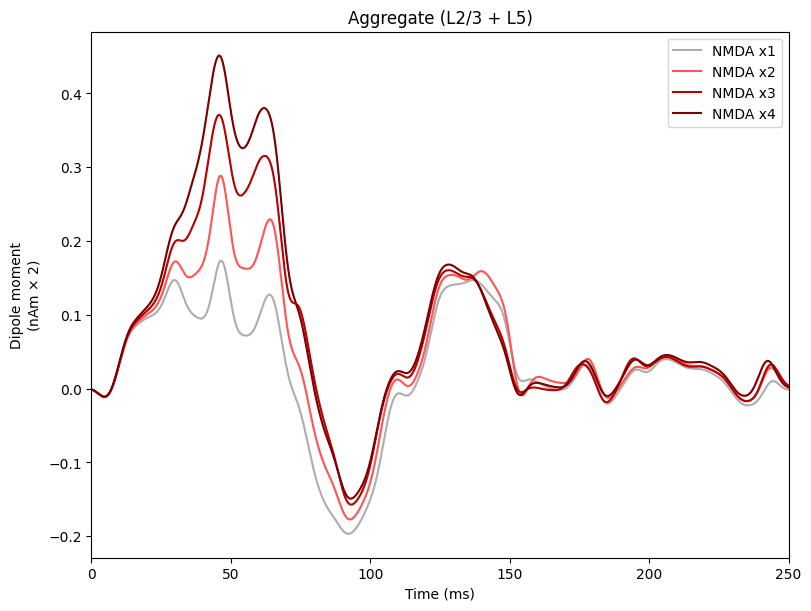

In [41]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
tstop=250
data_scale = 1
scale_list = [1,2,3,4]
color_list = ['#AEAEAE','#FF5555','#B80000','#7C0000']

# plot 2: dipoles and data
for idx, dpl in enumerate(smoothed_scaled_nmda_dpls):
    dpl_copy = deepcopy(dpl)
    plot_dipole(dpl_copy, ax = axes, layer='agg', show=False, average=True,label=f'NMDA x{scale_list[idx]}',color=color_list[idx])
axes.legend()
axes.set_xlim(0,tstop)

plt.savefig('TEP_change_nmda.png')